Dataset Shape: (891, 12)

First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0       

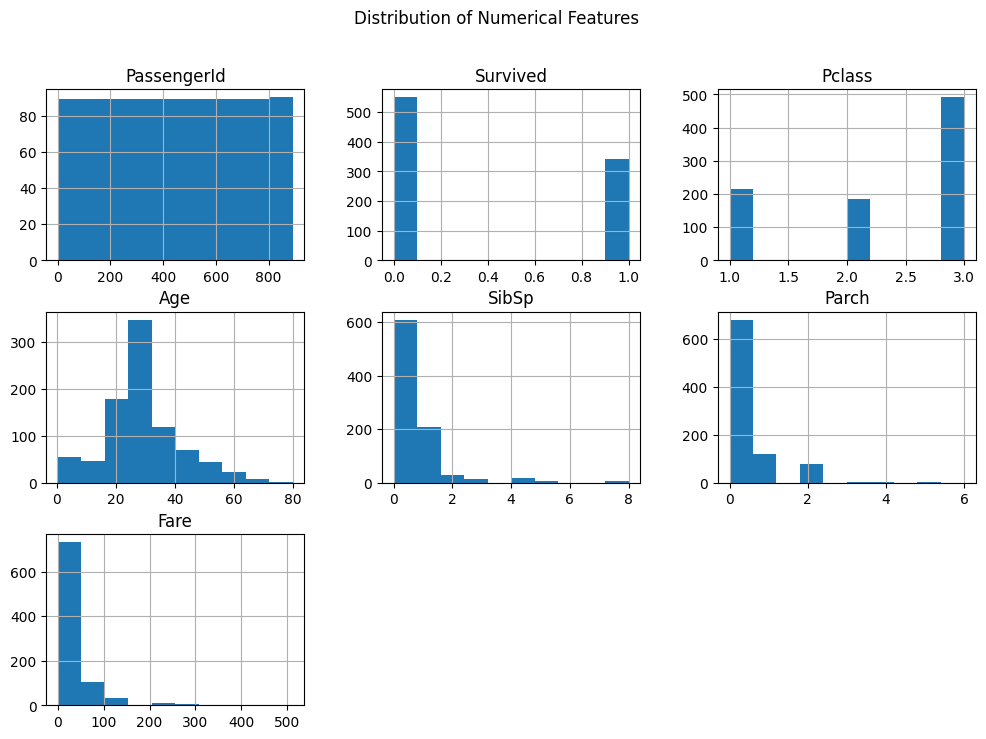

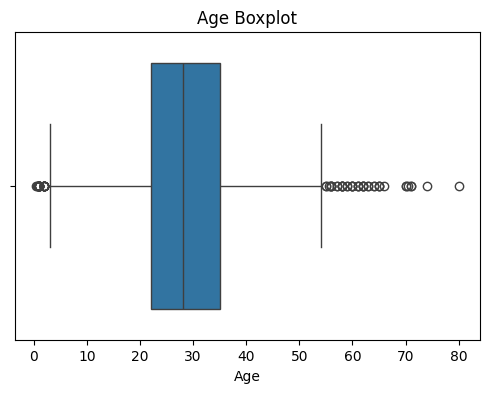

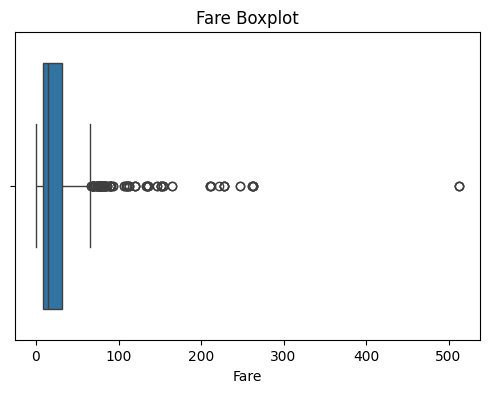

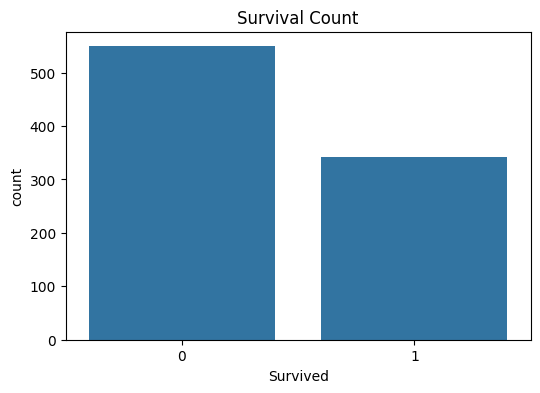

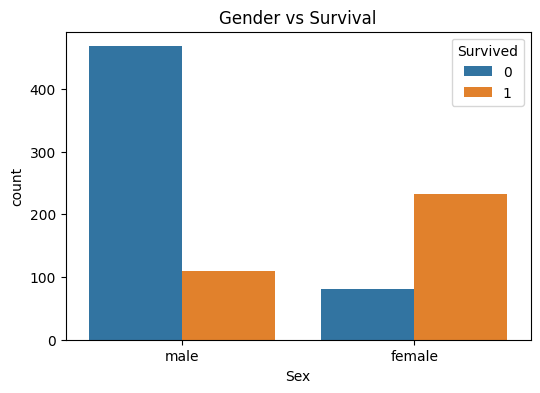

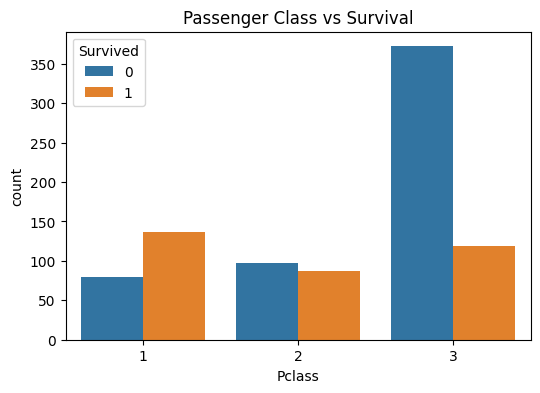

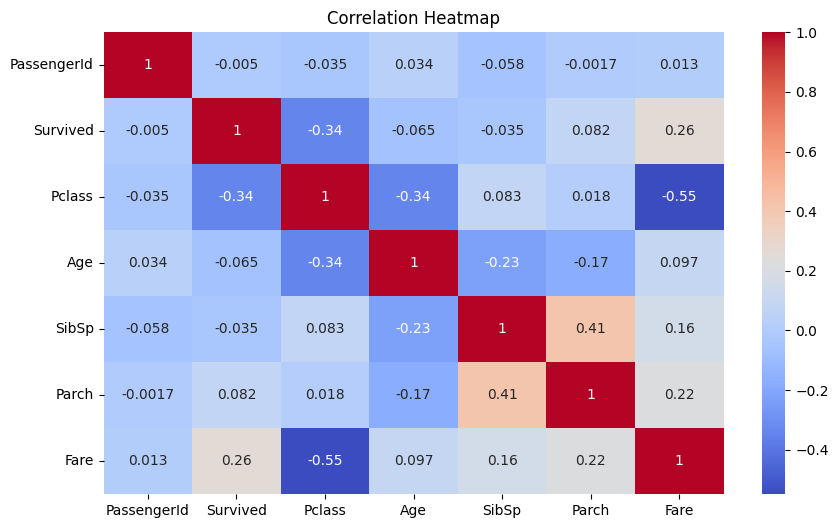

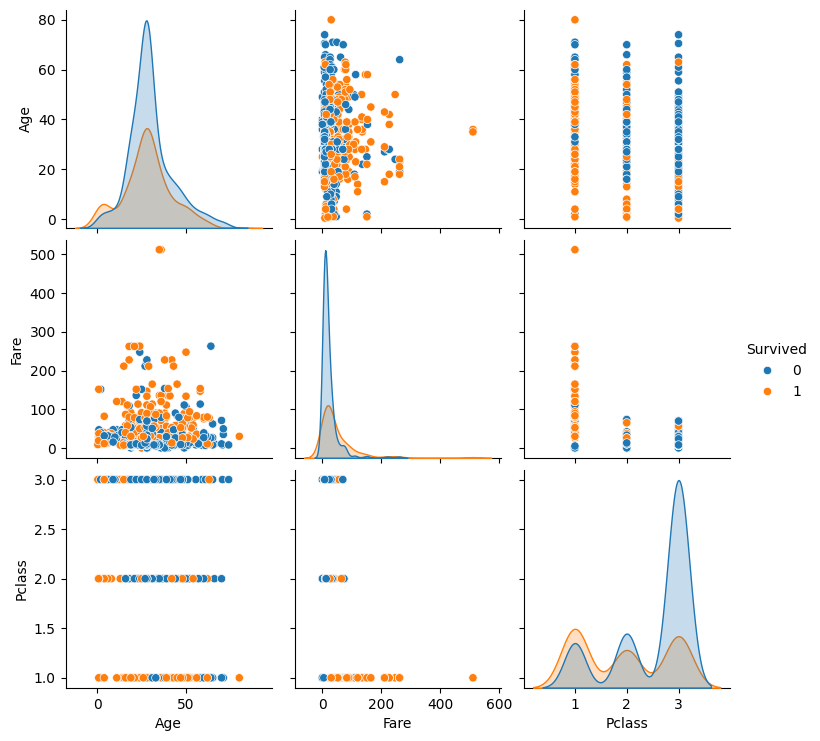

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("Titanic-Dataset.csv")

# Basic Information
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())

# Handle Missing Values
df["Age"] = df["Age"].fillna(df["Age"].median())

if "Embarked" in df.columns:
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

if "Fare" in df.columns:
    df["Fare"] = df["Fare"].fillna(df["Fare"].median())

if "Cabin" in df.columns:
    df = df.drop(columns=["Cabin"])

# Histograms
df.hist(figsize=(12, 8))
plt.suptitle("Distribution of Numerical Features")
plt.show()

# Boxplot - Age
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["Age"])
plt.title("Age Boxplot")
plt.show()

# Boxplot - Fare
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["Fare"])
plt.title("Fare Boxplot")
plt.show()

# Survival Count
plt.figure(figsize=(6, 4))
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

# Gender vs Survival
plt.figure(figsize=(6, 4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Gender vs Survival")
plt.show()

# Passenger Class vs Survival
plt.figure(figsize=(6, 4))
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Passenger Class vs Survival")
plt.show()

# Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Pairplot
sns.pairplot(
    df[["Age", "Fare", "Pclass", "Survived"]],
    hue="Survived"
)
plt.show()